<a href="https://colab.research.google.com/github/matirova/Analisis-salarios-it-argentina/blob/main/Analisis_y_ML_Salarios_Sysarmy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1) **LIMPIEZA DE DATOS**

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [35]:
from google.colab import drive
drive.mount('/content/drive')
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/2023.1_Sysarmy_Encuesta de remuneracin salarial Argentina.csv")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,estoy_trabajando_en,donde_estas_trabajando,dedicacion,tipo_de_contrato,ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local,ultimo_salario_mensual_o_retiro_neto_en_tu_moneda_local,pagos_en_dolares,si_tu_sueldo_esta_dolarizado_cual_fue_el_ultimo_valor_del_dolar_que_tomaron,pagos_en_criptomonedas,que_porcentaje_o_monto_recibis_en_criptomonedas,...,salir_o_seguir_contestando_sobre_las_guardias,tenes_guardias,cuanto_cobras_por_guardia,porcentajebruto_o_neto,salir_o_seguir_contestando_sobre_estudios,tengo_edad,me_identifico_genero,sueldo_dolarizado,seniority,me_id_extra
0,Argentina,Buenos Aires,Full-Time,Staff (planta permanente),"475,480.00",396346,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,25,Varón Cis,False,Semi-Senior,Hombre Cis
1,Argentina,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),"260,000.00",220000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,27,Mujer Cis,False,Junior,Mujer Cis
2,Argentina,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),"106,350.00",88560,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,21,Varón Cis,False,Junior,Hombre Cis
3,Argentina,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),"339,000.00",283700,NaN,NaN,NaN,NaN,...,Terminar encuesta,No,0.00,Porcentaje de mi sueldo bruto,Responder sobre mis estudios,25,Varón Cis,False,Semi-Senior,Hombre Cis
4,Argentina,Río Negro,Full-Time,Staff (planta permanente),"380,000.00",320000,Mi sueldo está dolarizado (pero cobro en moned...,179,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,24,Varón Cis,True,Junior,Hombre Cis


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5767 entries, 0 to 5766
Data columns (total 50 columns):
 #   Column                                                                                Non-Null Count  Dtype  
---  ------                                                                                --------------  -----  
 0   estoy_trabajando_en                                                                   5767 non-null   object 
 1   donde_estas_trabajando                                                                5767 non-null   object 
 2   dedicacion                                                                            5767 non-null   object 
 3   tipo_de_contrato                                                                      5767 non-null   object 
 4   ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local                              5767 non-null   float64
 5   ultimo_salario_mensual_o_retiro_neto_en_tu_moneda_local                            

In [37]:
df.shape

(5767, 50)

In [38]:
df.isnull().sum()

,0
estoy_trabajando_en,0
donde_estas_trabajando,0
dedicacion,0
tipo_de_contrato,0
ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local,0
ultimo_salario_mensual_o_retiro_neto_en_tu_moneda_local,210
pagos_en_dolares,4216
si_tu_sueldo_esta_dolarizado_cual_fue_el_ultimo_valor_del_dolar_que_tomaron,4783
pagos_en_criptomonedas,5592
que_porcentaje_o_monto_recibis_en_criptomonedas,4977


In [39]:
pip install missingno

<Axes: >

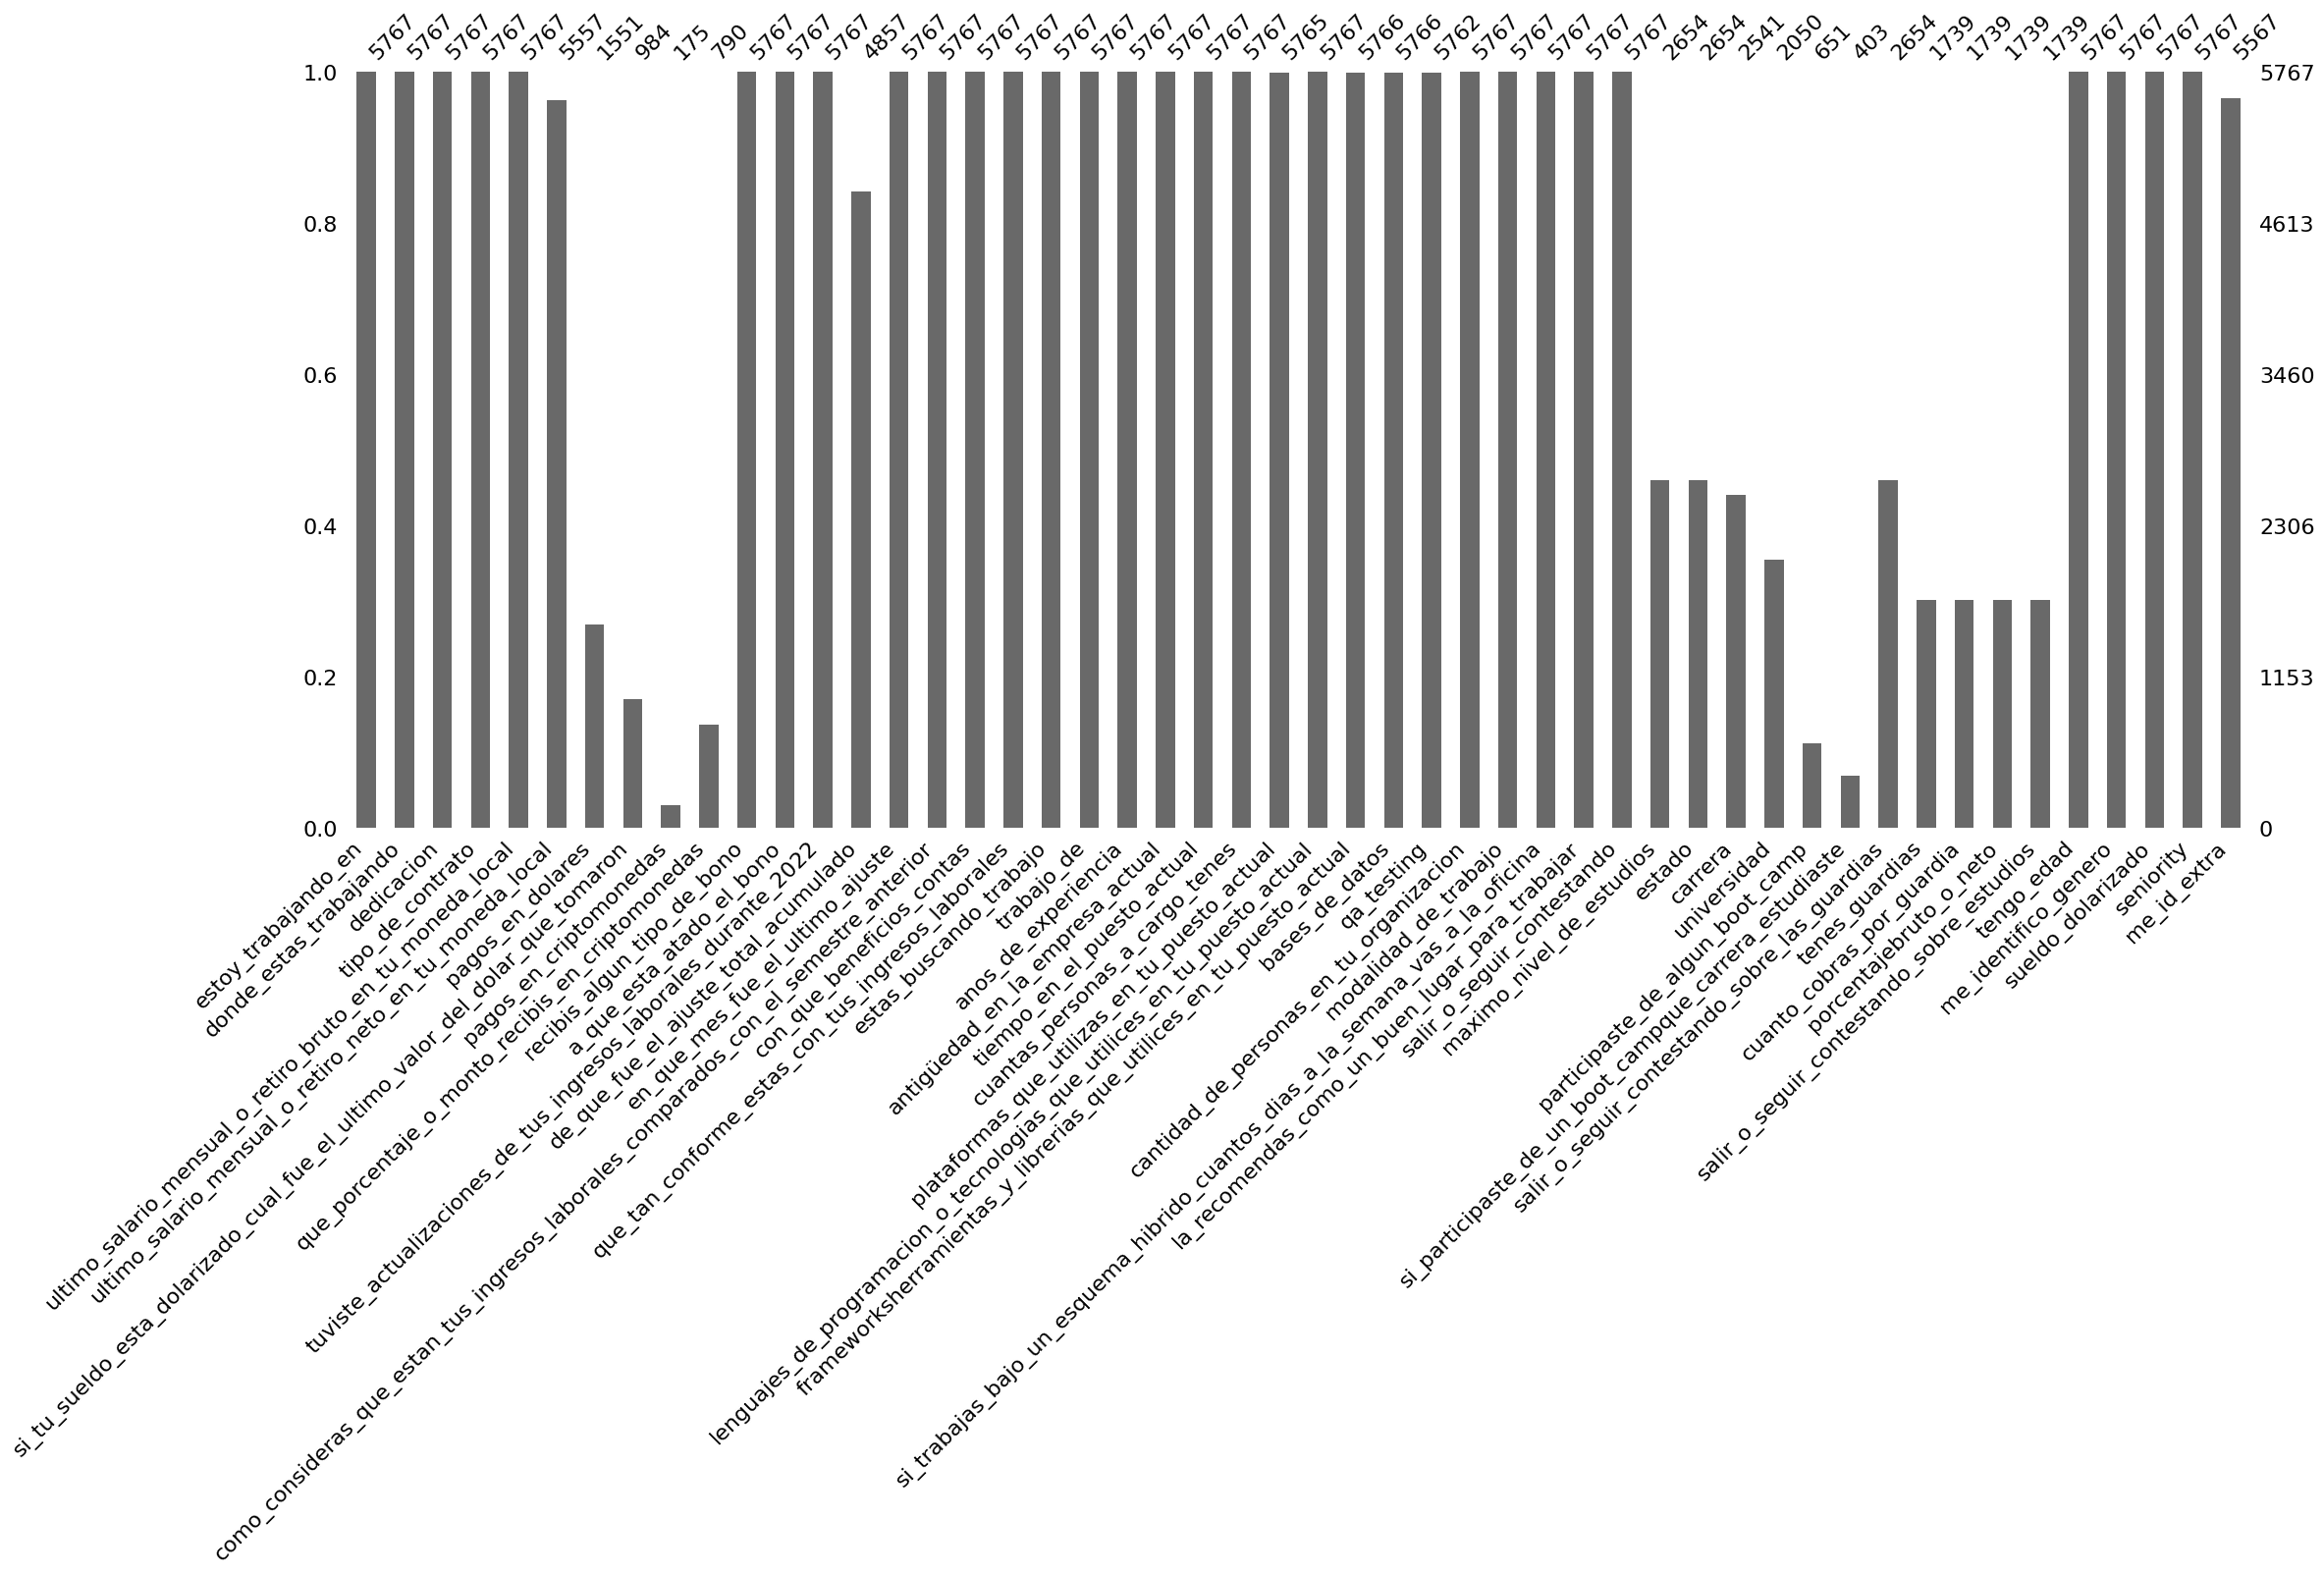

In [40]:
msno.bar(df)

<Axes: >

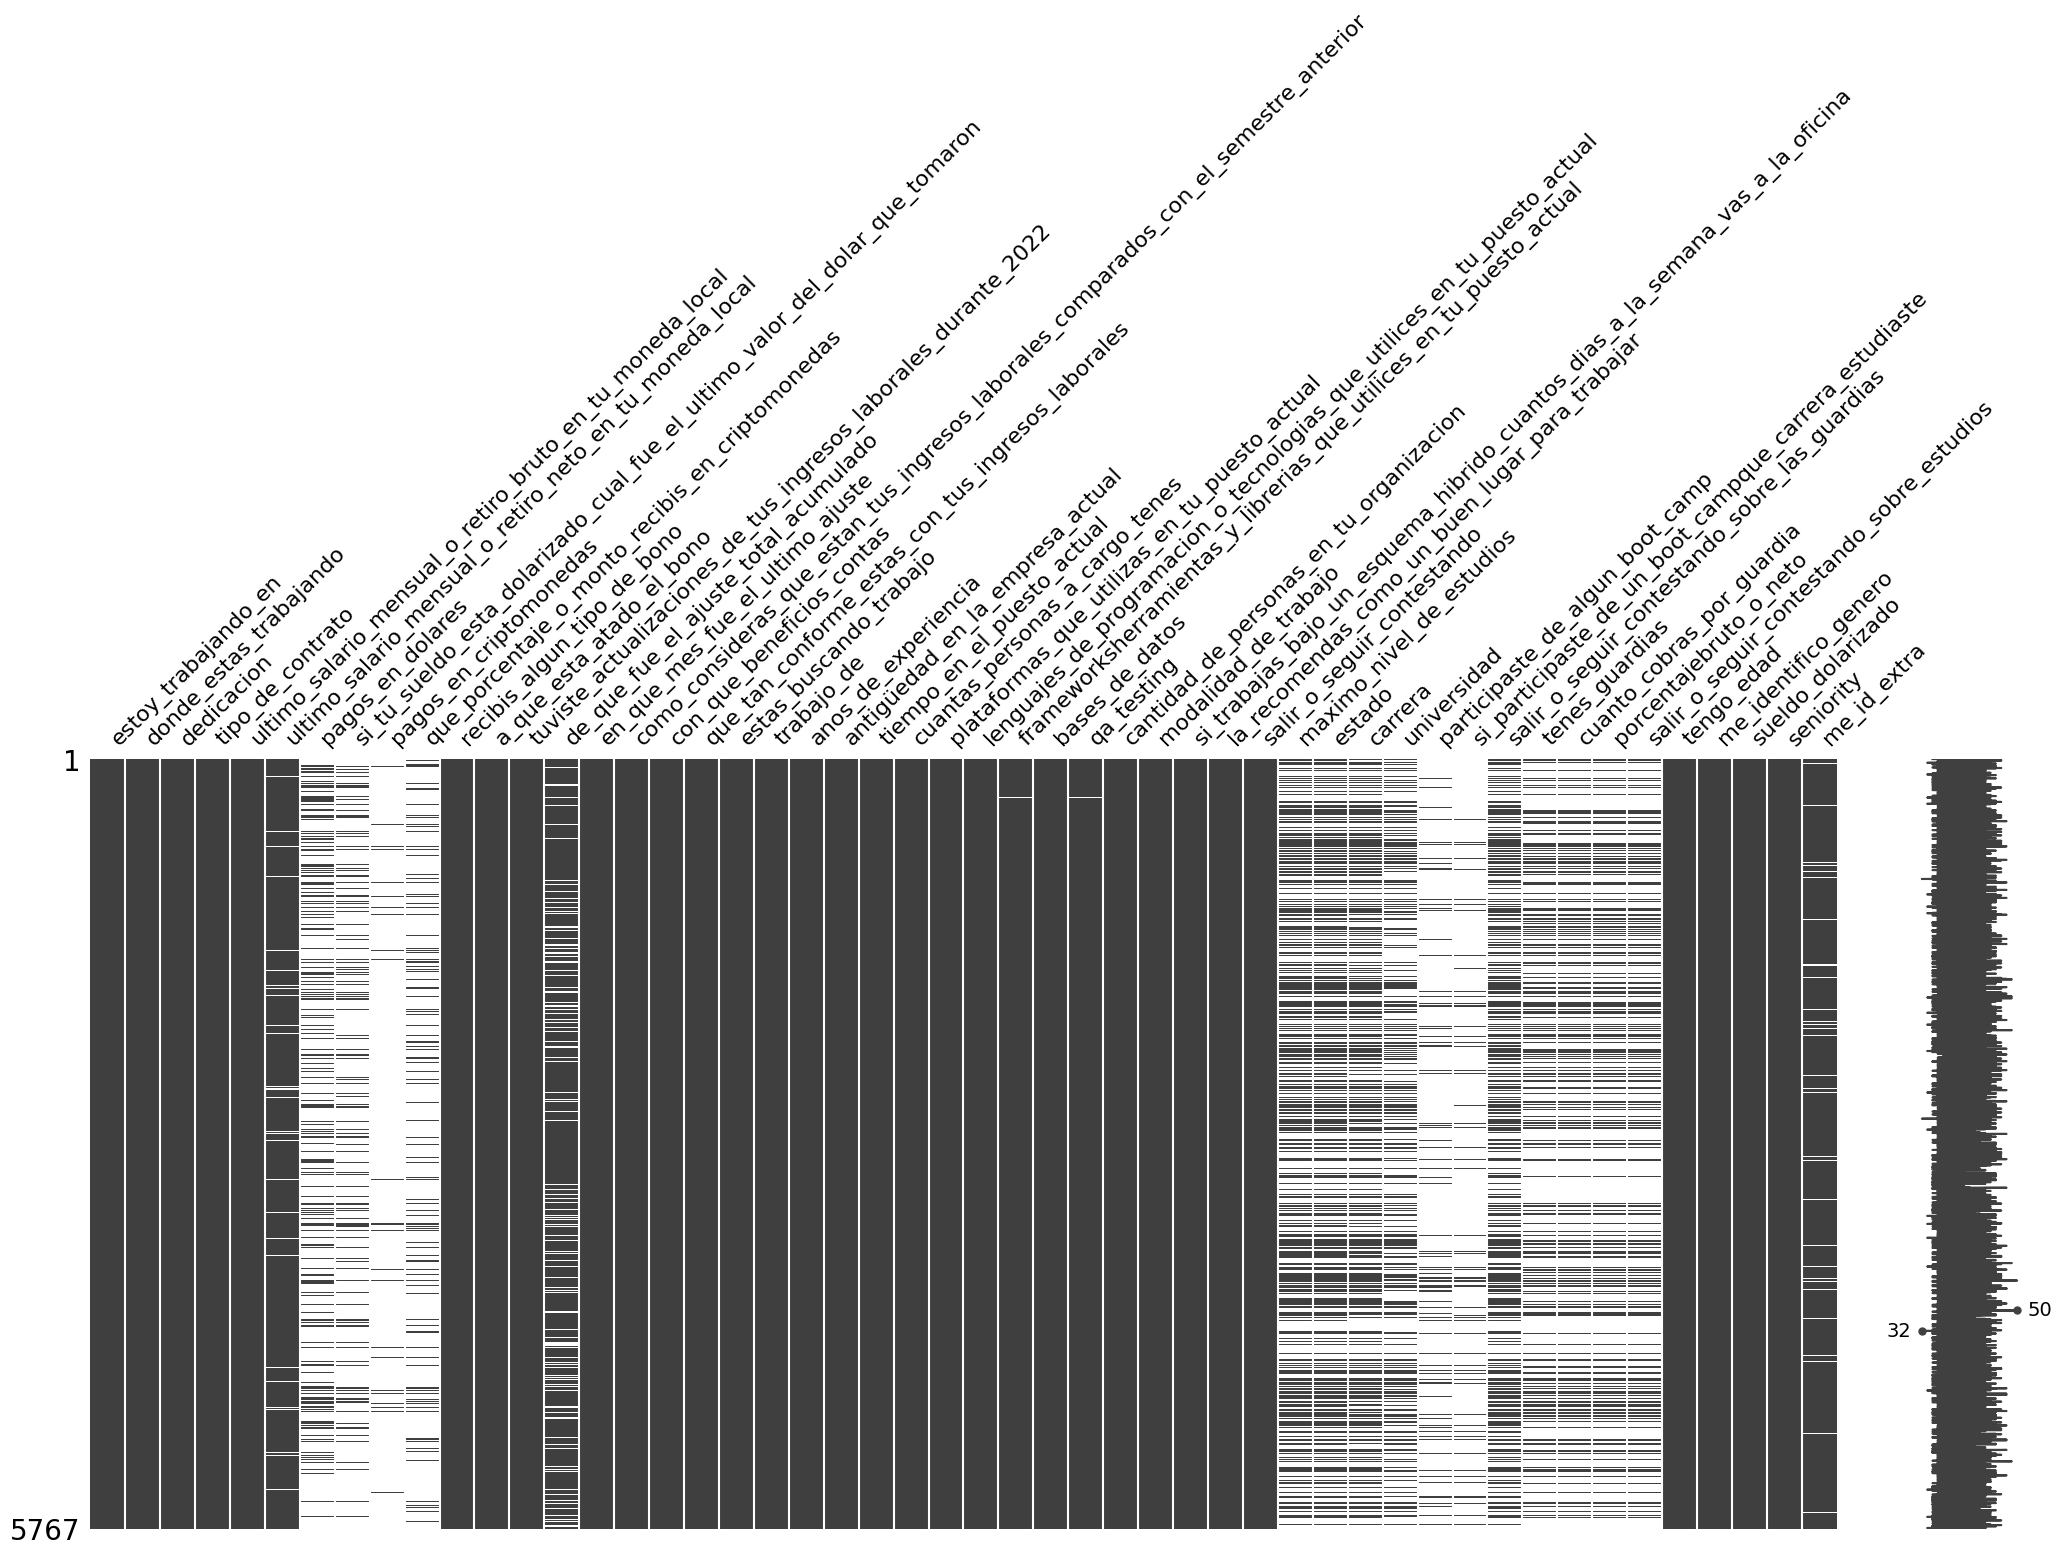

In [41]:
msno.matrix(df)

#2)**ANALISIS EXPLORATORIO DE DATOS**

In [42]:



df_limpio = df.copy()

df_limpio = df_limpio.dropna(subset=['ultimo_salario_mensual_o_retiro_neto_en_tu_moneda_local'])


for col in ['ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local',
            'ultimo_salario_mensual_o_retiro_neto_en_tu_moneda_local']:
    df_limpio[col] = pd.to_numeric(df_limpio[col].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')

df_limpio = df_limpio.dropna(subset=['ultimo_salario_mensual_o_retiro_neto_en_tu_moneda_local'])


df_limpio['que_porcentaje_o_monto_recibis_en_criptomonedas'] = df_limpio['que_porcentaje_o_monto_recibis_en_criptomonedas'].fillna(0)
df_limpio['pagos_en_dolares'] = df_limpio['pagos_en_dolares'].fillna('No')
df_limpio['pagos_en_criptomonedas'] = df_limpio['pagos_en_criptomonedas'].fillna('No')



df_limpio['maximo_nivel_de_estudios'] = df_limpio['maximo_nivel_de_estudios'].fillna('No especifica')
df_limpio['universidad'] = df_limpio['universidad'].fillna('No especifica')



q_low = df_limpio['ultimo_salario_mensual_o_retiro_neto_en_tu_moneda_local'].quantile(0.01)
q_hi  = df_limpio['ultimo_salario_mensual_o_retiro_neto_en_tu_moneda_local'].quantile(0.99)

df_limpio = df_limpio[(df_limpio['ultimo_salario_mensual_o_retiro_neto_en_tu_moneda_local'] > q_low) &
                    (df_limpio['ultimo_salario_mensual_o_retiro_neto_en_tu_moneda_local'] < q_hi)]


print(f"Filas originales: {df.shape[0]} | Filas después de la limpieza: {df_limpio.shape[0]}")

Filas originales: 5767 | Filas después de la limpieza: 5438


<Axes: >

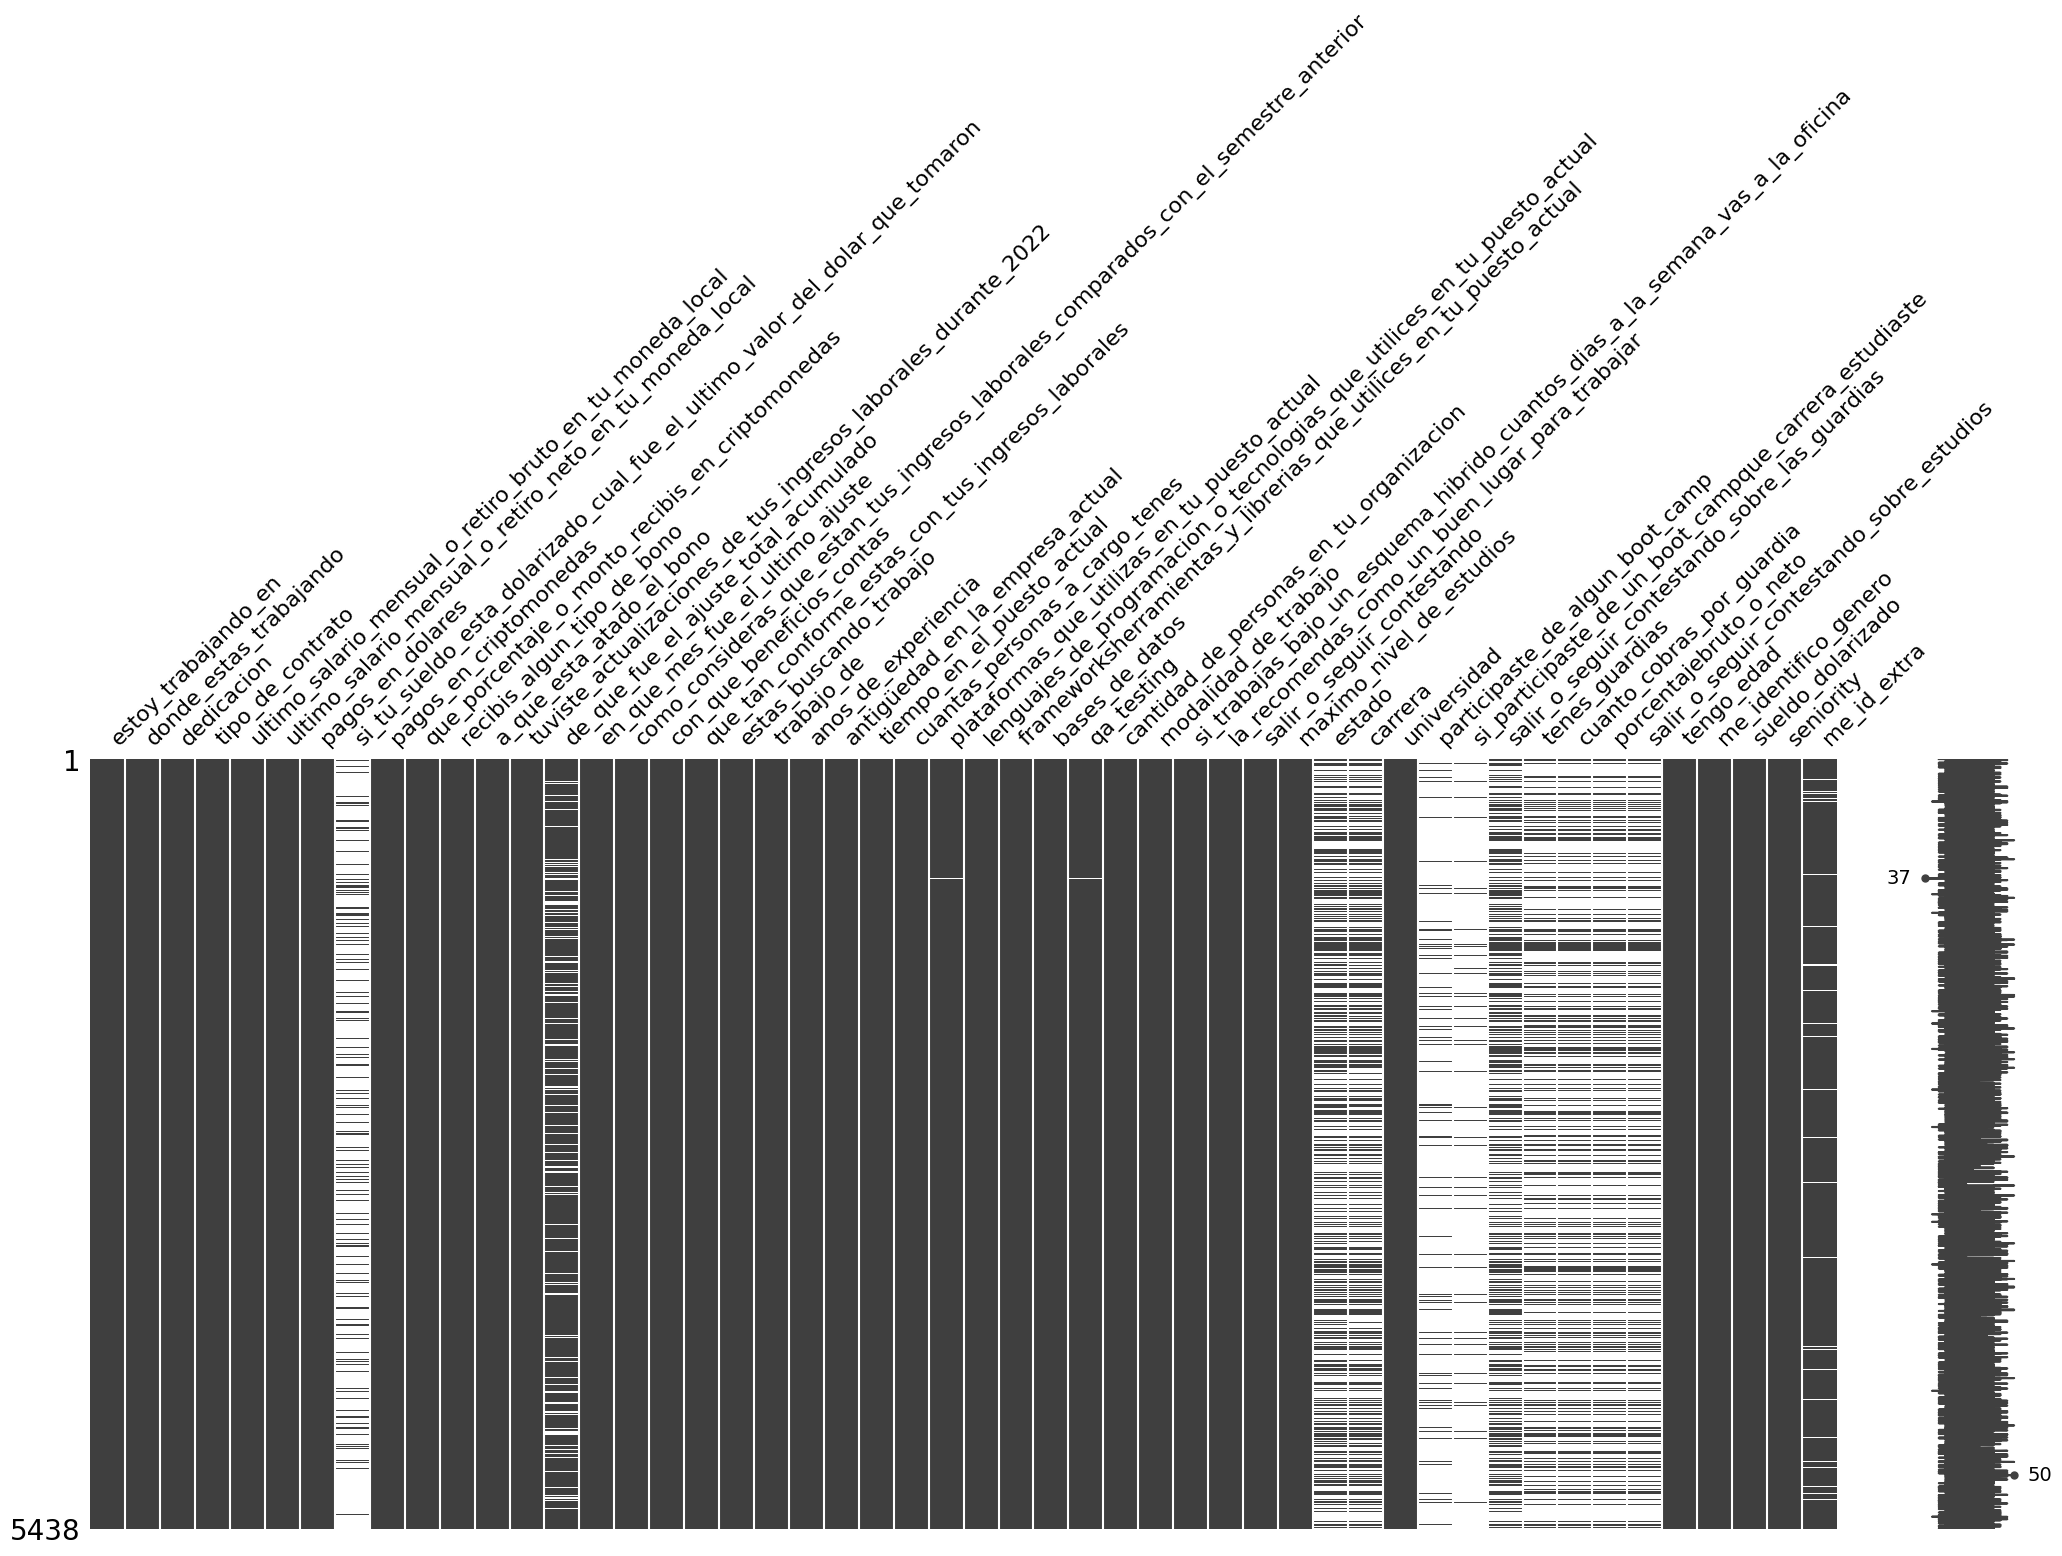

In [43]:
msno.matrix(df_limpio)

In [44]:
df_limpio.head()

,estoy_trabajando_en,donde_estas_trabajando,dedicacion,tipo_de_contrato,ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local,ultimo_salario_mensual_o_retiro_neto_en_tu_moneda_local,pagos_en_dolares,si_tu_sueldo_esta_dolarizado_cual_fue_el_ultimo_valor_del_dolar_que_tomaron,pagos_en_criptomonedas,que_porcentaje_o_monto_recibis_en_criptomonedas,...,salir_o_seguir_contestando_sobre_las_guardias,tenes_guardias,cuanto_cobras_por_guardia,porcentajebruto_o_neto,salir_o_seguir_contestando_sobre_estudios,tengo_edad,me_identifico_genero,sueldo_dolarizado,seniority,me_id_extra
0,Argentina,Buenos Aires,Full-Time,Staff (planta permanente),"475,480.00","396,346.00",No,NaN,No,0,...,NaN,NaN,NaN,NaN,NaN,25,Varón Cis,False,Semi-Senior,Hombre Cis
1,Argentina,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),"260,000.00","220,000.00",No,NaN,No,0,...,NaN,NaN,NaN,NaN,NaN,27,Mujer Cis,False,Junior,Mujer Cis
2,Argentina,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),"106,350.00","88,560.00",No,NaN,No,0,...,NaN,NaN,NaN,NaN,NaN,21,Varón Cis,False,Junior,Hombre Cis
3,Argentina,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),"339,000.00","283,700.00",No,NaN,No,0,...,Terminar encuesta,No,0.00,Porcentaje de mi sueldo bruto,Responder sobre mis estudios,25,Varón Cis,False,Semi-Senior,Hombre Cis
4,Argentina,Río Negro,Full-Time,Staff (planta permanente),"380,000.00","320,000.00",Mi sueldo está dolarizado (pero cobro en moned...,179,No,0,...,NaN,NaN,NaN,NaN,NaN,24,Varón Cis,True,Junior,Hombre Cis


In [45]:
df_limpio.columns

Index(['estoy_trabajando_en', 'donde_estas_trabajando', 'dedicacion',
       'tipo_de_contrato',
       'ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local',
       'ultimo_salario_mensual_o_retiro_neto_en_tu_moneda_local',
       'pagos_en_dolares',
       'si_tu_sueldo_esta_dolarizado_cual_fue_el_ultimo_valor_del_dolar_que_tomaron',
       'pagos_en_criptomonedas',
       'que_porcentaje_o_monto_recibis_en_criptomonedas',
       'recibis_algun_tipo_de_bono', 'a_que_esta_atado_el_bono',
       'tuviste_actualizaciones_de_tus_ingresos_laborales_durante_2022',
       'de_que_fue_el_ajuste_total_acumulado',
       'en_que_mes_fue_el_ultimo_ajuste',
       'como_consideras_que_estan_tus_ingresos_laborales_comparados_con_el_semestre_anterior',
       'con_que_beneficios_contas',
       'que_tan_conforme_estas_con_tus_ingresos_laborales',
       'estas_buscando_trabajo', 'trabajo_de', 'anos_de_experiencia',
       'antigüedad_en_la_empresa_actual', 'tiempo_en_el_puesto_actual',
      

In [46]:
df_limpio=df_limpio.rename(
    columns={ 'estoy_trabajando_en':"Pais",
    "donde_estas_trabajando":"Provincia",
    'ultimo_salario_mensual_o_retiro_bruto_en_tu_moneda_local':"Salario_bruto",
       'ultimo_salario_mensual_o_retiro_neto_en_tu_moneda_local':"Salario_neto",
       'si_tu_sueldo_esta_dolarizado_cual_fue_el_ultimo_valor_del_dolar_que_tomaron':"Cotizacion_dolar",
       'recibis_algun_tipo_de_bono':"Bono",
              'a_que_esta_atado_el_bono':"Motivo_de_bono",
              'tuviste_actualizaciones_de_tus_ingresos_laborales_durante_2022':"Actualizaciones_de_sueldo",
               'de_que_fue_el_ajuste_total_acumulado':"Ajuste_acumulado",
               'en_que_mes_fue_el_ultimo_ajuste':"ultimo_ajuste",
              'como_consideras_que_estan_tus_ingresos_laborales_comparados_con_el_semestre_anterior':"Comparacion_sueldo_semestre_anterior",
       'con_que_beneficios_contas':"Beneficios",
              'que_tan_conforme_estas_con_tus_ingresos_laborales':"COnformidad_Sueldo",
       'estas_buscando_trabajo':"Busqueda_laboral",
              'trabajo_de':"Puesto_laboral",
              'anos_de_experiencia':"Años_de_exp",
              'cuantas_personas_a_cargo_tenes':"Personas_a_cargo",
       'plataformas_que_utilizas_en_tu_puesto_actual':"Plataformas",
       'lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual':"Lenguajes",
       'frameworksherramientas_y_librerias_que_utilices_en_tu_puesto_actual':"Herramientas",
               'cantidad_de_personas_en_tu_organizacion':"Cant_personas_en_la_organizacion",
       'si_trabajas_bajo_un_esquema_hibrido_cuantos_dias_a_la_semana_vas_a_la_oficina':"Dias_oficina",
       'la_recomendas_como_un_buen_lugar_para_trabajar':"score_recomendacion",
               'salir_o_seguir_contestando':"Continuar_encuesta",
              'maximo_nivel_de_estudios':"Nivel_estudios",
              'participaste_de_algun_boot_camp':"Hizo_bootcamp",
       'si_participaste_de_un_boot_campque_carrera_estudiaste':"Bootcamp_estudios",
       'salir_o_seguir_contestando_sobre_las_guardias':"Acepta_guardias",
               'tenes_guardias':"Guardias",
       'cuanto_cobras_por_guardia':"Cobro_guardia",
              'porcentajebruto_o_neto':"Bruto_o_neto",
       'salir_o_seguir_contestando_sobre_estudios':"Seguir_contestando",
              'tengo_edad':"Edad",
              'me_identifico_genero':"Genero"
              }
    )
df_limpio.head()

,Pais,Provincia,dedicacion,tipo_de_contrato,Salario_bruto,Salario_neto,pagos_en_dolares,Cotizacion_dolar,pagos_en_criptomonedas,que_porcentaje_o_monto_recibis_en_criptomonedas,...,Acepta_guardias,Guardias,Cobro_guardia,Bruto_o_neto,Seguir_contestando,Edad,Genero,sueldo_dolarizado,seniority,me_id_extra
0,Argentina,Buenos Aires,Full-Time,Staff (planta permanente),"475,480.00","396,346.00",No,NaN,No,0,...,NaN,NaN,NaN,NaN,NaN,25,Varón Cis,False,Semi-Senior,Hombre Cis
1,Argentina,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),"260,000.00","220,000.00",No,NaN,No,0,...,NaN,NaN,NaN,NaN,NaN,27,Mujer Cis,False,Junior,Mujer Cis
2,Argentina,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),"106,350.00","88,560.00",No,NaN,No,0,...,NaN,NaN,NaN,NaN,NaN,21,Varón Cis,False,Junior,Hombre Cis
3,Argentina,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),"339,000.00","283,700.00",No,NaN,No,0,...,Terminar encuesta,No,0.00,Porcentaje de mi sueldo bruto,Responder sobre mis estudios,25,Varón Cis,False,Semi-Senior,Hombre Cis
4,Argentina,Río Negro,Full-Time,Staff (planta permanente),"380,000.00","320,000.00",Mi sueldo está dolarizado (pero cobro en moned...,179,No,0,...,NaN,NaN,NaN,NaN,NaN,24,Varón Cis,True,Junior,Hombre Cis


#3)**VISUALIZACIONES**

In [47]:
df_limpio.columns = df_limpio.columns.str.capitalize()
df_limpio.columns

Index(['Pais', 'Provincia', 'Dedicacion', 'Tipo_de_contrato', 'Salario_bruto',
       'Salario_neto', 'Pagos_en_dolares', 'Cotizacion_dolar',
       'Pagos_en_criptomonedas',
       'Que_porcentaje_o_monto_recibis_en_criptomonedas', 'Bono',
       'Motivo_de_bono', 'Actualizaciones_de_sueldo', 'Ajuste_acumulado',
       'Ultimo_ajuste', 'Comparacion_sueldo_semestre_anterior', 'Beneficios',
       'Conformidad_sueldo', 'Busqueda_laboral', 'Puesto_laboral',
       'Años_de_exp', 'Antigüedad_en_la_empresa_actual',
       'Tiempo_en_el_puesto_actual', 'Personas_a_cargo', 'Plataformas',
       'Lenguajes', 'Herramientas', 'Bases_de_datos', 'Qa_testing',
       'Cant_personas_en_la_organizacion', 'Modalidad_de_trabajo',
       'Dias_oficina', 'Score_recomendacion', 'Continuar_encuesta',
       'Nivel_estudios', 'Estado', 'Carrera', 'Universidad', 'Hizo_bootcamp',
       'Bootcamp_estudios', 'Acepta_guardias', 'Guardias', 'Cobro_guardia',
       'Bruto_o_neto', 'Seguir_contestando', 'Edad', '

In [48]:
pd.options.display.float_format = '{:,.2f}'.format
df_limpio.describe()


,Salario_bruto,Salario_neto,Ajuste_acumulado,Comparacion_sueldo_semestre_anterior,Conformidad_sueldo,Años_de_exp,Antigüedad_en_la_empresa_actual,Tiempo_en_el_puesto_actual,Personas_a_cargo,Dias_oficina,Score_recomendacion,Cobro_guardia
count,"5,438.00","5,438.00","4,575.00","5,438.00","5,438.00","5,438.00","5,438.00","5,438.00","5,438.00","5,438.00","5,438.00","1,649.00"
mean,"427,331.85","337,482.93",135.64,2.66,2.60,7.09,2.98,2.49,2.05,0.67,6.71,"31,933.88"
std,"288,793.70","227,393.50","3,258.46",0.83,0.85,7.08,4.48,27.48,8.27,1.15,2.82,"151,822.81"
min,"68,000.00","33,000.00",0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,"227,000.00","195,000.00",20.00,2.00,2.00,2.00,0.00,0.00,0.00,0.00,6.00,0.00
50%,"350,000.00","280,000.00",59.00,3.00,3.00,4.00,1.50,1.00,0.00,0.00,7.00,0.00
75%,"529,750.00","391,687.00",85.00,3.00,3.00,10.00,3.00,3.00,1.00,1.00,9.00,0.00
max,"1,736,000.00","1,480,000.00","200,000.00",4.00,4.00,48.00,75.00,"2,016.00",200.00,5.00,10.00,"2,500,000.00"


In [49]:

df_limpio['Edad'] = pd.to_numeric(df_limpio['Edad'], errors='coerce')

mediana_edad = df_limpio['Edad'].median()
df_limpio['Edad'] = df_limpio['Edad'].fillna(mediana_edad).astype(int)

print(df_limpio['Edad'].dtype)

int64


In [50]:

sueldo_por_seniority = df_limpio.groupby('Seniority')['Salario_neto'].median().reset_index()
sueldo_por_seniority = sueldo_por_seniority.sort_values(by='Salario_neto')
sueldo_por_seniority

,Seniority,Salario_neto
0,Junior,"197,000.00"
1,Semi-Senior,"290,000.00"
2,Senior,"345,750.00"


In [51]:

sueldo_por_modalidad = df_limpio.groupby('Modalidad_de_trabajo')['Salario_neto'].agg(['count', 'median'])
sueldo_por_modalidad.columns = ['Cantidad_Empleados', 'Sueldo_Mediano']
sueldo_por_modalidad = sueldo_por_modalidad.sort_values(by='Sueldo_Mediano', ascending=False)
sueldo_por_modalidad

,Cantidad_Empleados,Sueldo_Mediano
Modalidad_de_trabajo,,
100% remoto,3143,"295,000.00"
Híbrido (presencial y remoto),1852,"281,458.50"
100% presencial,443,"200,000.00"


In [52]:
import pandas as pd


columna_tecnologias = 'Lenguajes'

df_tech = df_limpio[[columna_tecnologias, 'Salario_neto']].dropna().copy()

df_tech[columna_tecnologias] = df_tech[columna_tecnologias].astype(str).str.strip()

df_tech[columna_tecnologias] = df_tech[columna_tecnologias].str.split(r'\s*,\s*')
df_tech_explotado = df_tech.explode(columna_tecnologias)

df_tech_explotado = df_tech_explotado[df_tech_explotado[columna_tecnologias] != '']

reporte_tech = df_tech_explotado.groupby(columna_tecnologias)['Salario_neto'].agg(['count', 'median'])

reporte_tech = reporte_tech[reporte_tech['count'] >= 30]

top_5_tecnologias = reporte_tech.sort_values(by='median', ascending=False).head(5)

print(" Las 5 tecnologías/lenguajes mejor pagados en Argentina:")
top_5_tecnologias

 Las 5 tecnologías/lenguajes mejor pagados en Argentina:


,count,median
Lenguajes,,
Ruby,51,"432,500.00"
Swift,67,"380,000.00"
Groovy,98,"370,000.00"
Kotlin,164,"364,500.00"
Scala,58,"352,494.50"


In [53]:

brecha_moneda = df_limpio.groupby('Sueldo_dolarizado')['Salario_neto'].agg(['count', 'median', 'mean'])

brecha_moneda.columns = ['Cantidad_Personas', 'Sueldo_Mediano', 'Sueldo_Promedio']

total_respuestas = brecha_moneda['Cantidad_Personas'].sum()
brecha_moneda['Porcentaje_Mercado'] = (brecha_moneda['Cantidad_Personas'] / total_respuestas) * 100


brecha_moneda

,Cantidad_Personas,Sueldo_Mediano,Sueldo_Promedio,Porcentaje_Mercado
Sueldo_dolarizado,,,,
False,5141,"280,000.00","335,742.74",94.54
True,297,"320,000.00","367,605.22",5.46


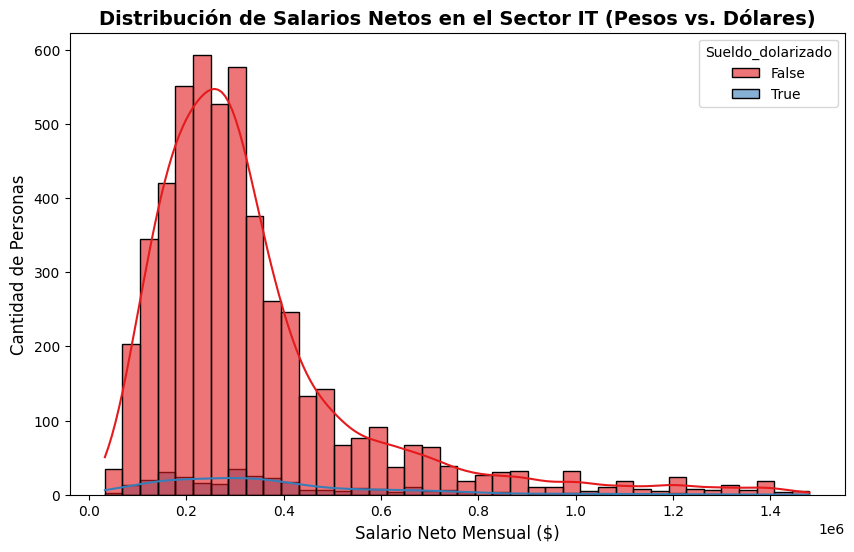

In [54]:
plt.figure (figsize=(10,6))
sns.histplot(data=df_limpio,x="Salario_neto",hue="Sueldo_dolarizado",kde=True,bins=40,multiple='layer',palette='Set1',alpha=0.6)

plt.title('Distribución de Salarios Netos en el Sector IT (Pesos vs. Dólares)', fontsize=14, fontweight='bold')
plt.xlabel('Salario Neto Mensual ($)', fontsize=12)
plt.ylabel('Cantidad de Personas', fontsize=12)

plt.show()

In [55]:
def limpiar_genero(texto):
    texto = str(texto).lower().strip()
    if 'varón' in texto or 'varon' in texto or 'hombre' in texto or 'masculino' in texto:
        return 'Varón'
    elif 'mujer' in texto or 'femenino' in texto:
        return 'Mujer'
    elif 'no binar' in texto or 'nobinar' in texto or 'queer' in texto:
        return 'No Binario'
    else:
        return 'Otros / Sin especificar'

df_limpio['Genero_Agrupado'] = df_limpio['Genero'].apply(limpiar_genero)

/tmp/ipykernel_12679/4133116454.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_limpio, x='Seniority', y='Salario_neto', ax=axes[0], palette='Set2',order=['Junior', 'Semi-Senior', 'Senior'])
/tmp/ipykernel_12679/4133116454.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_limpio, x='Genero_Agrupado', y='Salario_neto', palette='Pastel1',order=['Varón', 'Mujer', 'No Binario', 'Otros / Sin especificar'])


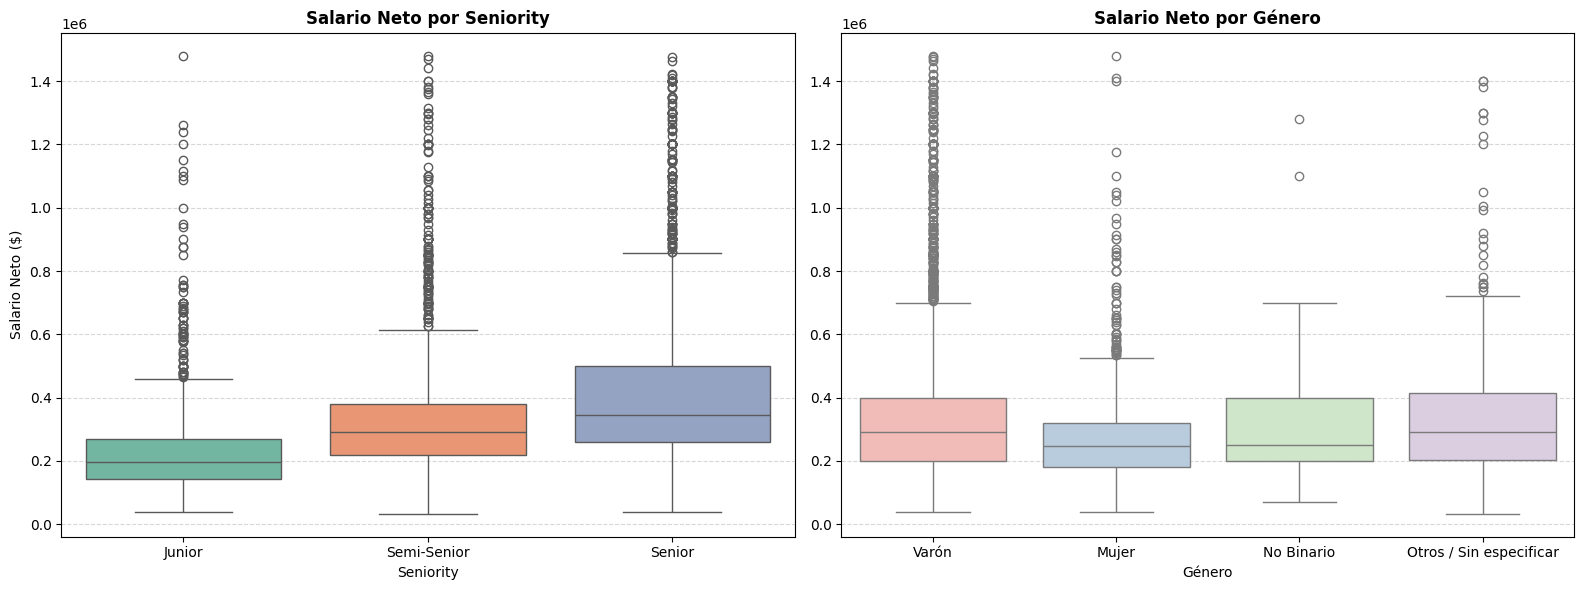

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=df_limpio, x='Seniority', y='Salario_neto', ax=axes[0], palette='Set2',order=['Junior', 'Semi-Senior', 'Senior'])
axes[0].set_title('Salario Neto por Seniority', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Seniority')
axes[0].set_ylabel('Salario Neto ($)')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

sns.boxplot(data=df_limpio, x='Genero_Agrupado', y='Salario_neto', palette='Pastel1',order=['Varón', 'Mujer', 'No Binario', 'Otros / Sin especificar'])
axes[1].set_title('Salario Neto por Género', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Género')
axes[1].set_ylabel('')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#4) **GUARDADO DE DATASET LIMPIO**

In [57]:
df_limpio.to_csv('/content/drive/MyDrive/encuesta_sysarmy_limpia.csv', index=False)

#5)**MACHINE LEARNING**

In [58]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

columnas_numericas = ['Edad', 'Años_de_exp', 'Sueldo_dolarizado']

columnas_texto = ['Seniority', 'Modalidad_de_trabajo', 'Genero_Agrupado']

todas_las_columnas = columnas_numericas + columnas_texto + ['Salario_neto']
df_ml_avanzado = df_limpio[todas_las_columnas].dropna()


df_binarizado = pd.get_dummies(df_ml_avanzado, columns=columnas_texto, drop_first=True)

X = df_binarizado.drop(columns=['Salario_neto'])
y = df_binarizado['Salario_neto']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_recargado = DecisionTreeRegressor(max_depth=6, random_state=42)
modelo_recargado.fit(X_train, y_train)


predicciones = modelo_recargado.predict(X_test)
mae = mean_absolute_error(y_test, predicciones)
r2 = r2_score(y_test, predicciones)

print(f" Nuevo Error Promedio Absoluto (MAE): ${mae:,.2f}")
print(f" Nuevo Porcentaje de acierto (R² Score): {r2 * 100:.2f}%")


 Nuevo Error Promedio Absoluto (MAE): $140,723.73
 Nuevo Porcentaje de acierto (R² Score): 18.88%


In [59]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

df_para_modelo = df_limpio.copy()

df_para_modelo['Lenguajes'] = df_para_modelo['Lenguajes'].fillna('').astype(str).str.lower()

tecnologias_clave = ['python', 'javascript', 'java', 'ruby', 'swift', 'sql', 'typescript']

for tech in tecnologias_clave:
    df_para_modelo[f'usa_{tech}'] = df_para_modelo['Lenguajes'].apply(lambda x: 1 if tech in x else 0)

columnas_numericas = ['Edad', 'Años_de_exp', 'Sueldo_dolarizado']
columnas_texto = ['Seniority', 'Modalidad_de_trabajo', 'Genero_Agrupado']
columnas_tech_nuevas = [f'usa_{tech}' for tech in tecnologias_clave]

columnas_finales = columnas_numericas + columnas_texto + columnas_tech_nuevas + ['Salario_neto']
df_ml_final = df_para_modelo[columnas_finales].dropna()

df_binarizado = pd.get_dummies(df_ml_final, columns=columnas_texto, drop_first=True)

X = df_binarizado.drop(columns=['Salario_neto'])
y = df_binarizado['Salario_neto']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_final = DecisionTreeRegressor(max_depth=6, random_state=42)
modelo_final.fit(X_train, y_train)

predicciones = modelo_final.predict(X_test)
mae = mean_absolute_error(y_test, predicciones)
r2 = r2_score(y_test, predicciones)

print(f" Error Promedio Absoluto (MAE): ${mae:,.2f}")
print(f"Porcentaje de acierto (R² Score): {r2 * 100:.2f}%")

 Error Promedio Absoluto (MAE): $139,123.03
Porcentaje de acierto (R² Score): 19.86%


/tmp/ipykernel_12679/1824021688.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


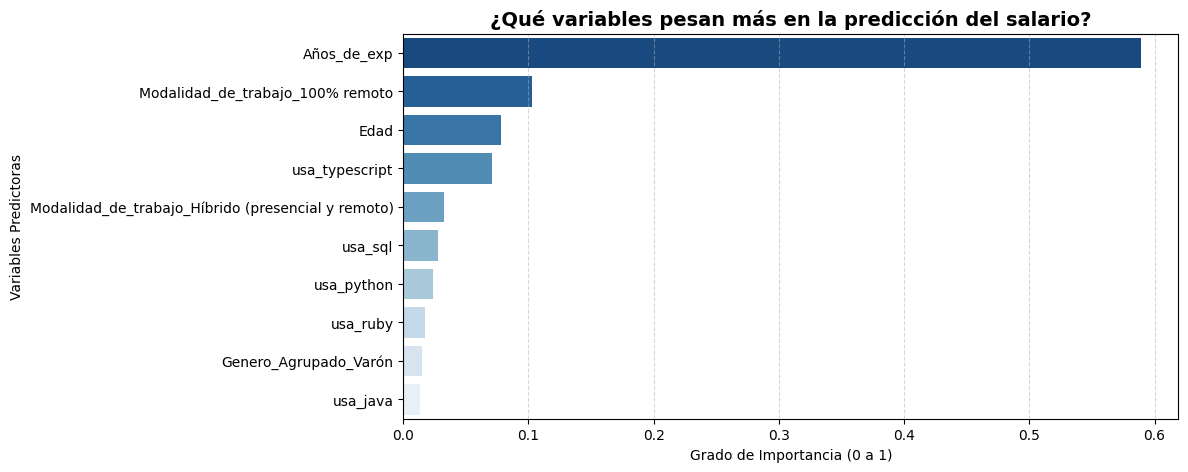

In [60]:
import numpy as np

importancias = modelo_final.feature_importances_
columnas_x = X.columns

df_importancias = pd.DataFrame({
    'Variable': columnas_x,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_importancias,
    x='Importancia',
    y='Variable',
    palette='Blues_r'
)

plt.title('¿Qué variables pesan más en la predicción del salario?', fontsize=14, fontweight='bold')
plt.xlabel('Grado de Importancia (0 a 1)')
plt.ylabel('Variables Predictoras')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()